In [1]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, root_mean_squared_error, accuracy_score

# Load the parquet file
file_path = 'ml_features_1m_v2.parquet'
df = pd.read_parquet(file_path)

# Display the first few rows to verify
df.head()

,market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
0,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:00:00+00:00,0.285,0.453750,0.45,0.005,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
1,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:01:00+00:00,0.285,0.450000,0.45,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
2,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:02:00+00:00,0.290,0.443333,0.44,0.005,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
3,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:03:00+00:00,0.290,0.440000,0.44,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,287.79,3845.07,-0.860731
4,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,2026-03-06 00:04:00+00:00,0.290,0.440000,0.44,0.000,0.0,0.0,0.0,0,0.0,0,0.000000,366.80,8838.88,-0.920310


In [2]:
# Convert minute_bar to datetime and sort to ensure chronological order
df['minute_bar'] = pd.to_datetime(df['minute_bar'])
df = df.sort_values('minute_bar')

# Define features (X) and target (y)
# Drop IDs, timestamps, and target-related columns from the feature set
drop_columns = ['market_id', 'minute_bar', 'target', 'return_1m']
X = df.drop(columns=drop_columns)
y = df['target'] 

# Perform a chronological split (e.g., first 80% for training, last 20% for testing)
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4470037, 12)
Testing data shape: (1117510, 12)


In [3]:
# Initialize the LightGBM model
# Switch to lgb.LGBMClassifier() if your target is categorical/binary
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# Train the model with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# Make predictions on the test set
predictions = model.predict(X_test)

# Evaluate the model (RMSE for regression)
rmse = root_mean_squared_error(y_test, predictions)
print(f"\nTest RMSE: {rmse:.6f}")

# If using LGBMClassifier, use this instead:
# print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.664255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2823
[LightGBM] [Info] Number of data points in the train set: 4470037, number of used features: 12
[LightGBM] [Info] Start training from score 0.268087
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's l2: 0.10146

Test RMSE: 0.318527


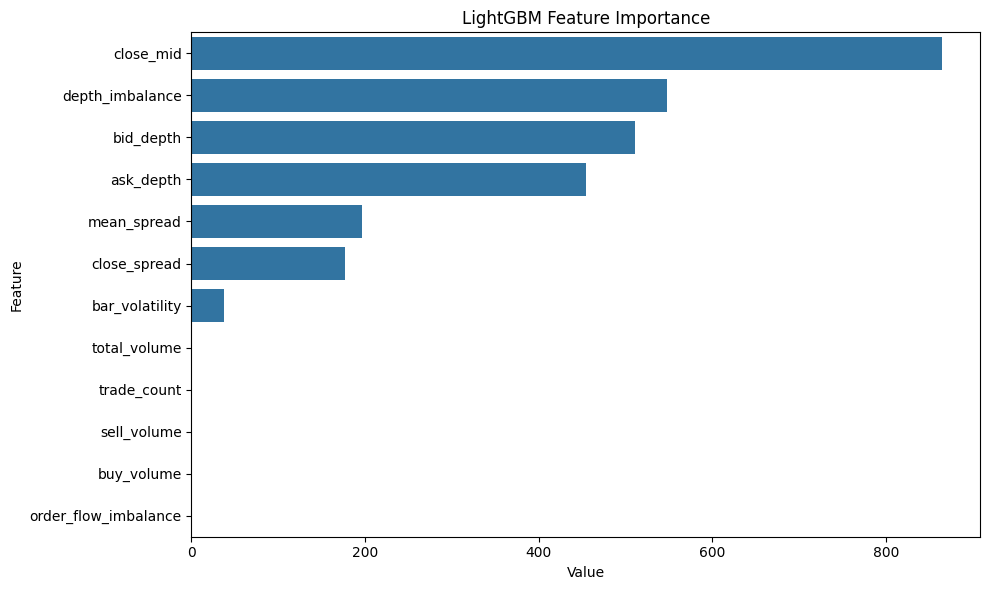

In [4]:
# Extract feature importances
feature_imp = pd.DataFrame({
    'Value': model.feature_importances_, 
    'Feature': X.columns
})

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Value", 
    y="Feature", 
    data=feature_imp.sort_values(by="Value", ascending=False)
)
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

# Análise de Importância das Variáveis (Feature Importance) - LightGBM

O gráfico gerado apresenta a **importância das features** (variáveis) calculada pelo modelo LightGBM. Esta métrica indica o quanto cada variável contribuiu para as decisões e divisões dentro das árvores do modelo para chegar na previsão final (geralmente medido pelo número de vezes que a variável foi usada para dividir os dados, conhecido como *split*, ou pelo ganho total na redução do erro, conhecido como *gain*).

Aqui está a interpretação detalhada dos seus resultados com base no gráfico gerado:

## 1. As Variáveis Mais Importantes (Os "Motores" do Modelo)
Estas são as variáveis que o modelo considerou mais úteis para prever o seu `target`.
* **`close_mid`**: É, de longe, a variável com maior dominância (com valor superando 800). O preço médio (mid-price) no fechamento do *minute bar* contém o maior poder preditivo do modelo atual. 
* **Variáveis de Livro de Ofertas (`depth_imbalance`, `bid_depth`, `ask_depth`)**: Formam o segundo bloco mais importante (valores entre 400 e 600). O modelo está extraindo um sinal forte da liquidez do mercado (profundidade das ofertas de compra e venda) e, principalmente, do desequilíbrio entre essas pontas. Isso indica que a dinâmica da microestrutura do livro de ofertas é essencial para a sua previsão.

## 2. Variáveis de Importância Moderada
* **`mean_spread` e `close_spread`**: As métricas de *spread* (a diferença entre o melhor preço de compra e venda) mostraram uma importância moderada (valores em torno de 200). Elas ajudam a refinar as previsões, provavelmente servindo como indicativos secundários da volatilidade ou do custo de liquidez.

## 3. Variáveis de Baixa Importância ou Ignoradas
Estas variáveis tiveram pouco ou nenhum impacto nas previsões finais. O LightGBM praticamente as ignorou ao construir as árvores de decisão.
* **`bar_volatility`**: Teve uma contribuição muito marginal, quase próxima a zero.
* **Métricas de Volume e Fluxo (`total_volume`, `trade_count`, `sell_volume`, `buy_volume`, `order_flow_imbalance`)**: Possuem barras invisíveis (importância zero). Isso significa que, frente às variáveis de preço e profundidade do livro, o volume negociado e a contagem de trades não agregaram nenhum ganho de informação para prever o `target`.

---

## 💡 Recomendações e Próximos Passos
1. **Seleção de Variáveis (Feature Selection)**: Você pode tentar **remover** as variáveis com importância zero do seu arquivo `.parquet` e rodar o treinamento do LightGBM novamente. Um modelo com menos variáveis (apenas as que importam) é mais rápido para treinar, generaliza melhor para dados novos e tem menos risco de sofrer *overfitting*.
2. **Engenharia de Features (Feature Engineering)**: Como o modelo demonstrou depender muito das métricas de livro de ofertas (`depth_imbalance`, `close_mid`), o próximo passo natural para tentar melhorar o *Test RMSE* é criar novas variáveis derivadas destas. Por exemplo:
   * A variação do `depth_imbalance` em relação ao minuto anterior.
   * Médias móveis exponenciais do `close_mid` e dos *spreads*.